In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
from currency_converter import CurrencyConverter
from datetime import date

## Read Data

In [2]:
# https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml
li_small_accounts_df = pd.read_csv('C:/Users/caleb/Downloads/ibm_aml/LI-Small_accounts.csv')
li_small_accounts_df

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,China Bank #2820,314693,81B86A280,800D8CCF0,Corporation #41344
1,France Bank #4585,311253,8187FEA80,800B505E0,Corporation #54497
2,China Bank #2242,39996,803961E00,800D03F60,Partnership #36904
3,National Bank of Newport,331440,81B075800,801567C10,Corporation #16224
4,UK Bank #33,135417,80CF87C80,801085E00,Partnership #72930
...,...,...,...,...,...
712683,China Bank #42,692,80346A5F0,800D080A0,Corporation #40025
712684,First Bank of Watertown,118699,80B802A70,8005319C0,Partnership #14803
712685,Bank of Lincoln,213123,80847BE70,800453480,Partnership #11893
712686,Hilltop Credit Union,18747,803A36270,8003B5120,Partnership #6726


In [3]:
li_small_trans_df = pd.read_csv('C:/Users/caleb/Downloads/ibm_aml/LI-Small_trans.csv')
li_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,3.195403e+06,US Dollar,3.195403e+06,US Dollar,Reinvestment,0
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,1.858960e+03,US Dollar,1.858960e+03,US Dollar,Reinvestment,0
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,5.925710e+05,US Dollar,5.925710e+05,US Dollar,Cheque,0
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,1.232000e+01,US Dollar,1.232000e+01,US Dollar,Reinvestment,0
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,2.941560e+03,US Dollar,2.941560e+03,US Dollar,Reinvestment,0
...,...,...,...,...,...,...,...,...,...,...,...
6924044,2022/09/10 23:39,71696,81B2518F1,71528,81C0482E1,3.346900e-02,Bitcoin,3.346900e-02,Bitcoin,Bitcoin,0
6924045,2022/09/10 23:48,271241,81B567481,173457,81C0DA751,1.313000e-03,Bitcoin,1.313000e-03,Bitcoin,Bitcoin,0
6924046,2022/09/10 23:50,271241,81B567481,173457,81C0DA751,1.305800e-02,Bitcoin,1.305800e-02,Bitcoin,Bitcoin,0
6924047,2022/09/10 23:57,170558,81A2206B1,275798,81C1D5CA1,4.145370e-01,Bitcoin,4.145370e-01,Bitcoin,Bitcoin,0


In [4]:
hi_small_accounts_df = pd.read_csv('C:/Users/caleb/Downloads/ibm_aml/HI-Small_accounts.csv')
hi_small_accounts_df

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889
...,...,...,...,...,...
518576,France Bank #33,3881,807886B70,80062D160,Sole Proprietorship #22257
518577,National Bank of Topeka,333423,81314C870,800F40230,Sole Proprietorship #4995
518578,Plandor Trust Bank,1467,804ED2270,800CAC4C0,Sole Proprietorship #35326
518579,Sappo Bancorp,2843,801727270,800EFCB40,Sole Proprietorship #3522


In [5]:
hi_small_trans_df = pd.read_csv('C:/Users/caleb/Downloads/ibm_aml/HI-Small_trans.csv')
hi_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.340000,US Dollar,3697.340000,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.570000,US Dollar,14675.570000,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.970000,US Dollar,2806.970000,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.970000,US Dollar,36682.970000,US Dollar,Reinvestment,0
...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0.154978,Bitcoin,0.154978,Bitcoin,Bitcoin,0
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0.108128,Bitcoin,0.108128,Bitcoin,Bitcoin,0
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0.004988,Bitcoin,0.004988,Bitcoin,Bitcoin,0
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0.038417,Bitcoin,0.038417,Bitcoin,Bitcoin,0


## Summarize Data

In [10]:
li_small_accounts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712688 entries, 0 to 712687
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Bank Name       712688 non-null  object
 1   Bank ID         712688 non-null  int64 
 2   Account Number  712688 non-null  object
 3   Entity ID       712688 non-null  object
 4   Entity Name     712688 non-null  object
dtypes: int64(1), object(4)
memory usage: 27.2+ MB


In [11]:
li_small_trans_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6924049 entries, 0 to 6924048
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Timestamp           6924049 non-null  object 
 1   From Bank           6924049 non-null  int64  
 2   Account             6924049 non-null  object 
 3   To Bank             6924049 non-null  int64  
 4   Account.1           6924049 non-null  object 
 5   Amount Received     6924049 non-null  float64
 6   Receiving Currency  6924049 non-null  object 
 7   Amount Paid         6924049 non-null  float64
 8   Payment Currency    6924049 non-null  object 
 9   Payment Format      6924049 non-null  object 
 10  Is Laundering       6924049 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 581.1+ MB


In [12]:
hi_small_accounts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518581 entries, 0 to 518580
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Bank Name       518581 non-null  object
 1   Bank ID         518581 non-null  int64 
 2   Account Number  518581 non-null  object
 3   Entity ID       518581 non-null  object
 4   Entity Name     518581 non-null  object
dtypes: int64(1), object(4)
memory usage: 19.8+ MB


In [13]:
hi_small_trans_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Timestamp           5078345 non-null  object 
 1   From Bank           5078345 non-null  int64  
 2   Account             5078345 non-null  object 
 3   To Bank             5078345 non-null  int64  
 4   Account.1           5078345 non-null  object 
 5   Amount Received     5078345 non-null  float64
 6   Receiving Currency  5078345 non-null  object 
 7   Amount Paid         5078345 non-null  float64
 8   Payment Currency    5078345 non-null  object 
 9   Payment Format      5078345 non-null  object 
 10  Is Laundering       5078345 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


There are no null values in any of the datasets

The account dataframes show details about accounts, what bank the account belongs to, and the business entity that owns the bank account

The transactions show different types of payments between accounts

The reasoning for the datasets being split into two groups is as follows:

- Group HI has a relatively higher illicit ratio (more laundering).
- Group LI has a relatively lower illicit ratio (less laundering).

In [14]:
len(hi_small_accounts_df['Account Number'].unique())

518573

In [ ]:
hi_small_trans_df.describe()

,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering
count,5078345.00000,5078345.00000,5078345.00000,5078345.00000,5078345.00000
mean,45730.56573,65744.56285,5988726.07007,4509273.36774,0.00102
std,81765.62228,84092.99014,1037183108.89199,869772830.91986,0.03191
min,1.00000,1.00000,0.00000,0.00000,0.00000
25%,119.00000,4259.00000,183.37000,184.48000,0.00000
50%,9679.00000,21568.00000,1411.01000,1414.54000,0.00000
75%,28628.00000,122332.00000,12346.27000,12297.84000,0.00000
max,356303.00000,356294.00000,1046302363293.47998,1046302363293.47998,1.00000


In [ ]:
li_small_trans_df.describe()

,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering
count,6924049.00000,6924049.00000,6924049.00000,6924049.00000,6924049.00000
mean,59387.18465,84417.01768,6324066.60518,4676035.97267,0.00051
std,90517.00160,90645.61637,2105371139.59929,1544098506.68412,0.02268
min,0.00000,0.00000,0.00000,0.00000,0.00000
25%,219.00000,11255.00000,174.21000,175.38000,0.00000
50%,14195.00000,29640.00000,1397.62000,1399.44000,0.00000
75%,110682.00000,148040.00000,12296.33000,12226.87000,0.00000
max,376967.00000,376967.00000,3644853662746.95020,3644853662746.95020,1.00000


In [ ]:
li_small_trans_df.sort_values(by="Amount Paid").tail(5)

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
510834,2022/09/01 01:46,123800,808B7F870,119699,809CE4D70,387153034505.19000,Rupee,387153034505.19000,Rupee,Cash,0
1334434,2022/09/01 19:57,215278,8068972A0,123135,8145F9B50,665312317878.07996,Yen,665312317878.07996,Yen,Cheque,0
6883964,2022/09/10 20:14,25552,80ABDDA10,23494,80ABDF080,677986739551.35999,Rupee,677986739551.35999,Rupee,ACH,0
3007683,2022/09/04 13:44,123260,80A274810,2,80A286620,862339995114.23999,Rupee,862339995114.23999,Rupee,ACH,0
2525880,2022/09/02 23:06,11047,8018B08B0,22297,8157483D0,3644853662746.95020,Yen,3644853662746.95020,Yen,Cheque,0


In [39]:
li_small_trans_df['Payment Currency'].unique()

array(['US Dollar', 'Euro', 'Bitcoin', 'Yuan', 'Yen', 'UK Pound',
       'Brazil Real', 'Australian Dollar', 'Rupee', 'Ruble',
       'Canadian Dollar', 'Mexican Peso', 'Swiss Franc', 'Shekel',
       'Saudi Riyal'], dtype=object)

## Preprocess the Amounts for Currency Conversion

In [40]:
li_small_trans_df[li_small_trans_df['Receiving Currency'] != li_small_trans_df['Payment Currency']]

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
2770,2022/09/01 00:12,394,80056EDE0,394,80056EDE0,47.61000,Euro,55.79000,US Dollar,ACH,0
8081,2022/09/01 00:28,11701,800C95BF0,11701,800C95BF0,954.62000,Yuan,142.53000,US Dollar,ACH,0
10451,2022/09/01 00:18,22481,80105E630,22481,80105E630,16930.03000,Yen,160.63000,US Dollar,ACH,0
12948,2022/09/01 00:17,1439,8014545C0,1439,8014545C0,14.52000,UK Pound,18.76000,US Dollar,ACH,0
13799,2022/09/01 00:02,20,8015D68E0,20,8015D68E0,37.00000,Euro,43.35000,US Dollar,ACH,0
...,...,...,...,...,...,...,...,...,...,...,...
6924007,2022/09/10 23:57,9096,80356BD61,9096,80356BD60,0.00001,Bitcoin,0.39000,Yuan,ACH,0
6924009,2022/09/10 23:30,9096,80356BD61,9096,80356BD60,0.00001,Bitcoin,0.55000,Yuan,ACH,0
6924019,2022/09/10 23:38,13474,803A93631,13474,803A93630,0.00001,Bitcoin,0.08000,US Dollar,ACH,0
6924021,2022/09/10 23:31,13474,803A93631,13474,803A93630,0.00002,Bitcoin,0.23000,US Dollar,ACH,0


We want to maintain the Payment/Receiving Currency, since it indicates if a transaction was sent/received in the same country. We should scale all the currencys to a single currency like Dollar to make them comparable.

In [ ]:
# 1 of XYZ currency to USD as of 9/1/2022 via https://www.exchangerates.org.uk/historical/.../01_09_2022
usd_to_usd = 1
euro_to_usd = 0.9945
btc_to_usd = 20050.50 # Opening BTC price
yuan_to_usd =  0.1446
yen_to_usd = 0.0071
pound_to_usd = 1.154
brazil_to_usd = 0.1907
aus_to_usd = 0.6789
rupee_to_usd =  0.0125 # Assuming Indian Rupee
ruble_to_usd = 0.0166
canadian_to_usd = 0.7601
peso_to_usd = 0.0495
swiss_to_usd = 1.0184
shekel_to_usd = 0.2943
riyal_to_usd = 0.266

In [ ]:
currency_map = {
    'US Dollar': usd_to_usd,
    'Euro': euro_to_usd, 
    'Bitcoin': btc_to_usd, 
    'Yuan': yuan_to_usd, 
    'Yen': yen_to_usd, 
    'UK Pound': pound_to_usd,
    'Brazil Real': brazil_to_usd,
    'Australian Dollar': aus_to_usd, 
    'Rupee': rupee_to_usd, 
    'Ruble': ruble_to_usd,
    'Canadian Dollar': canadian_to_usd, 
    'Mexican Peso': peso_to_usd, 
    'Swiss Franc': swiss_to_usd, 
    'Shekel': shekel_to_usd,
    'Saudi Riyal': riyal_to_usd,
}

In [ ]:
li_small_trans_df['Amount_Received_USD'] = li_small_trans_df.apply(lambda row: row['Amount Received'] * currency_map[row['Receiving Currency']], axis=1)
li_small_trans_df['Amount_Paid_USD'] = li_small_trans_df.apply(lambda row: row['Amount Paid'] * currency_map[row['Payment Currency']], axis=1)

In [ ]:
hi_small_trans_df['Amount_Received_USD'] = hi_small_trans_df.apply(lambda row: row['Amount Received'] * currency_map[row['Receiving Currency']], axis=1)
hi_small_trans_df['Amount_Paid_USD'] = hi_small_trans_df.apply(lambda row: row['Amount Paid'] * currency_map[row['Payment Currency']], axis=1)

## Check for Inifinite Values and Duplicates

In [15]:
hi_small_accounts_num_df = hi_small_accounts_df.select_dtypes(include=[np.number])

# Find rows where ANY column has an infinite value
rows_with_inf = hi_small_accounts_df[np.isinf(hi_small_accounts_num_df).any(axis=1)]
rows_with_inf

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name


In [16]:
li_small_accounts_num_df = li_small_accounts_df.select_dtypes(include=[np.number])
# Find rows where ANY column has an infinite value
rows_with_inf = li_small_accounts_df[np.isinf(li_small_accounts_num_df).any(axis=1)]
rows_with_inf

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name


In [17]:
hi_small_trans_num_df = hi_small_trans_df.select_dtypes(include=[np.number])

# Find rows where ANY column has an infinite value
rows_with_inf = hi_small_trans_df[np.isinf(hi_small_trans_num_df).any(axis=1)]
rows_with_inf

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering


In [18]:
li_small_trans_num_df = li_small_trans_df.select_dtypes(include=[np.number])

# Find rows where ANY column has an infinite value
rows_with_inf = li_small_trans_df[np.isinf(li_small_trans_num_df).any(axis=1)]
rows_with_inf

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering


There are no inf values

In [19]:
hi_small_accounts_df[hi_small_accounts_df.duplicated(keep=False)]

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name


In [20]:
li_small_accounts_df[li_small_accounts_df.duplicated(keep=False)]

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name


In [21]:
hi_small_trans_df[hi_small_trans_df.duplicated(keep=False)]

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
863293,2022/09/01 16:20,12004,800C927C1,12004,800C927C0,0.000008,Bitcoin,0.080000,Euro,ACH,0
863294,2022/09/01 16:20,12004,800C927C1,220,813D8C1E1,0.000008,Bitcoin,0.000008,Bitcoin,Bitcoin,0
863295,2022/09/01 16:20,12004,800C927C1,12004,800C927C0,0.000008,Bitcoin,0.080000,Euro,ACH,0
863296,2022/09/01 16:20,12004,800C927C1,220,813D8C1E1,0.000008,Bitcoin,0.000008,Bitcoin,Bitcoin,0
3684003,2022/09/07 21:25,29992,8099A29B1,220,813725AE1,0.000003,Bitcoin,0.000003,Bitcoin,Bitcoin,0
3684005,2022/09/07 21:25,29992,8099A29B1,220,813725AE1,0.000003,Bitcoin,0.000003,Bitcoin,Bitcoin,0
4166784,2022/09/08 21:05,113779,811144AB1,113779,811144AB0,0.000002,Bitcoin,0.020000,US Dollar,ACH,0
4166785,2022/09/08 21:05,113779,811144AB1,53744,813C777F1,0.000002,Bitcoin,0.000002,Bitcoin,Bitcoin,0
4166786,2022/09/08 21:05,113779,811144AB1,113779,811144AB0,0.000002,Bitcoin,0.020000,US Dollar,ACH,0
4166787,2022/09/08 21:05,113779,811144AB1,53744,813C777F1,0.000002,Bitcoin,0.000002,Bitcoin,Bitcoin,0


In [22]:
li_small_trans_df[li_small_trans_df.duplicated(keep=False)]

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
676694,2022/09/01 05:03,21260,8085A09D1,72146,81AB967E1,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0
676696,2022/09/01 05:03,21260,8085A09D1,72146,81AB967E1,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0
790828,2022/09/01 07:44,231616,814E45511,171546,81B324AC1,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0
790830,2022/09/01 07:44,231616,814E45511,171546,81B324AC1,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0
2027614,2022/09/02 11:09,28335,804B468F1,171669,81BBCDAB1,0.000007,Bitcoin,0.000007,Bitcoin,Bitcoin,0
2027616,2022/09/02 11:09,28335,804B468F1,171669,81BBCDAB1,0.000007,Bitcoin,0.000007,Bitcoin,Bitcoin,0
3482551,2022/09/05 12:44,22661,80D016C81,269294,81A245E81,0.000005,Bitcoin,0.000005,Bitcoin,Bitcoin,0
3482553,2022/09/05 12:44,22661,80D016C81,269294,81A245E81,0.000005,Bitcoin,0.000005,Bitcoin,Bitcoin,0
4180129,2022/09/06 14:16,19970,804E44F11,169489,8197DC971,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0
4180131,2022/09/06 14:16,19970,804E44F11,169489,8197DC971,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0


The identified duplicates are duplicate transactions. Since this just means the same amount is sent between the same accounts, I will leave these as valid samples.

## Boxplots

<Axes: >

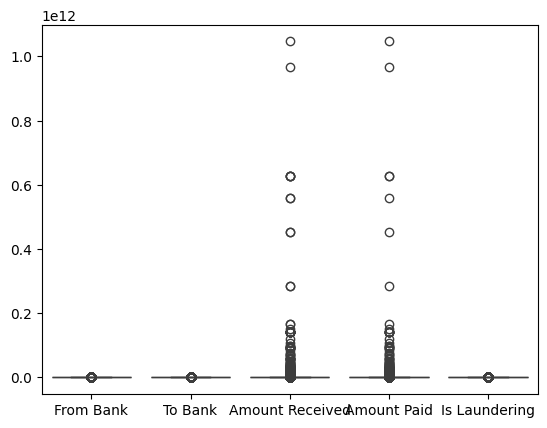

In [23]:
sns.boxplot(hi_small_trans_df)

<Axes: >

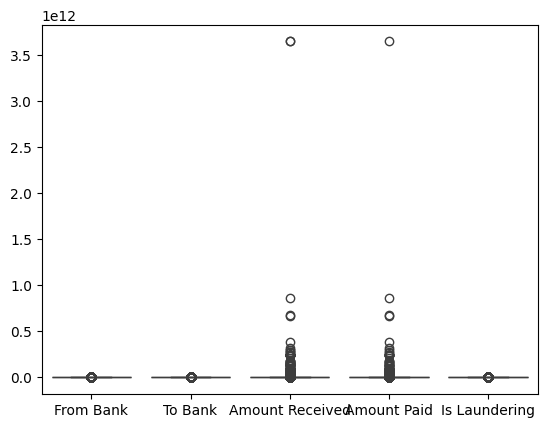

In [24]:
sns.boxplot(li_small_trans_df)

## Correlations

<Axes: >

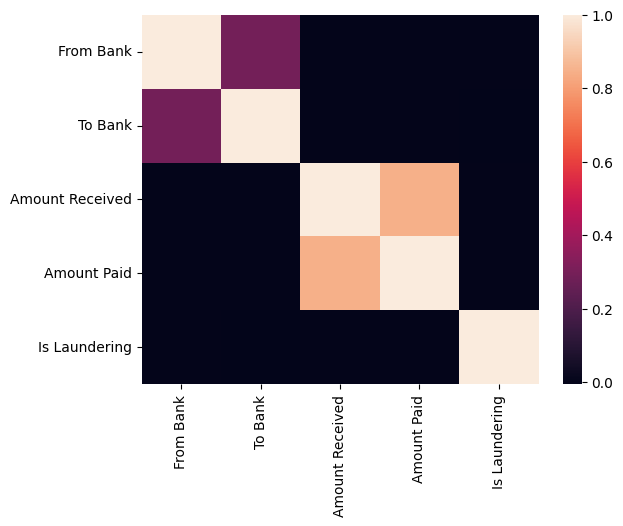

In [25]:
sns.heatmap(hi_small_trans_df.corr(numeric_only=True))

<Axes: >

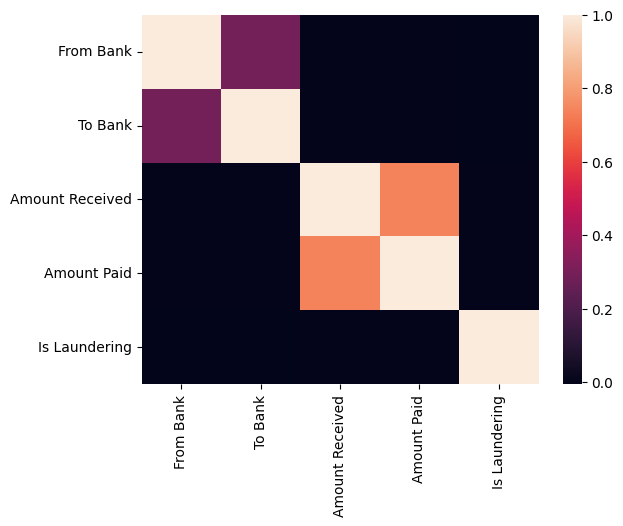

In [26]:
sns.heatmap(li_small_trans_df.corr(numeric_only=True))

We see a strong correlation between Amount Received/Paid and To/From Bank. The other combinations do not have correlation.

The relationship between the Amounts is expected, since each transaction contains two accounts and the Received/Paid should mirror each other. We can see that in the scatterplot below.

I expect that the relationships in the data will reveal themselves not through just checking correlations, but by building a model of how transactions fit together. We need a full picture of how money flows throughout many transactions.

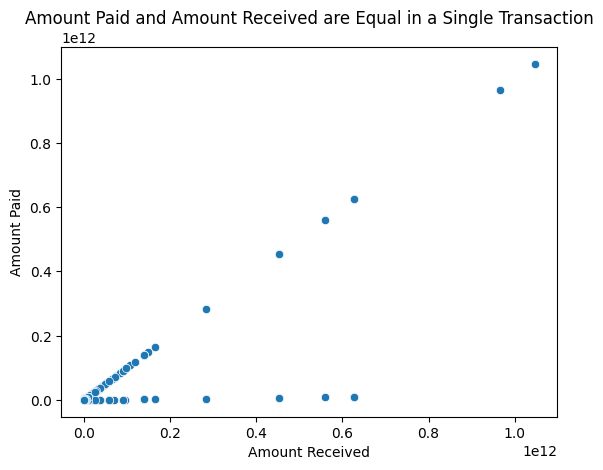

In [27]:
sns.scatterplot(x=hi_small_trans_df['Amount Received'], y=hi_small_trans_df['Amount Paid'])
plt.title("Amount Paid and Amount Received are Equal in a Single Transaction")
None

## Timeline of Transactions for a Sample Account

In [28]:
# Plotting a timeline of transactions that contains money laundering
hi_small_trans_df[hi_small_trans_df['Is Laundering'] == 1]

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
4742,2022/09/01 00:21,70,100428660,1124,800825340,389769.39,US Dollar,389769.39,US Dollar,Cheque,1
40621,2022/09/01 00:03,70,100428660,11474,805B716C0,29024.33,US Dollar,29024.33,US Dollar,Credit Card,1
69152,2022/09/01 00:01,70,100428660,15980,80B39E7B0,792.92,US Dollar,792.92,US Dollar,Credit Card,1
85763,2022/09/01 00:03,70,100428660,113798,80DC756E0,13171425.53,US Dollar,13171425.53,US Dollar,Cheque,1
90684,2022/09/01 00:23,70,100428660,32375,80E480620,14288.83,US Dollar,14288.83,US Dollar,Cash,1
...,...,...,...,...,...,...,...,...,...,...,...
5071168,2022/09/10 23:29,111433,8065C2380,21550,8065C69E0,7773.42,US Dollar,7773.42,US Dollar,ACH,1
5073375,2022/09/10 23:07,9,80727F930,219557,8072A28C0,448920.65,Ruble,448920.65,Ruble,Cheque,1
5074248,2022/09/12 03:34,222,812D127D0,50202,812D129C0,20085.71,Saudi Riyal,20085.71,Saudi Riyal,ACH,1
5075056,2022/09/10 23:43,17327,8095F6C20,15695,8095F6C70,3314.36,US Dollar,3314.36,US Dollar,ACH,1


C:\Users\caleb\AppData\Local\Temp\ipykernel_25740\1523918599.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hi_transactions_sample['Timestamp_Date'] = pd.to_datetime(hi_transactions_sample['Timestamp'])


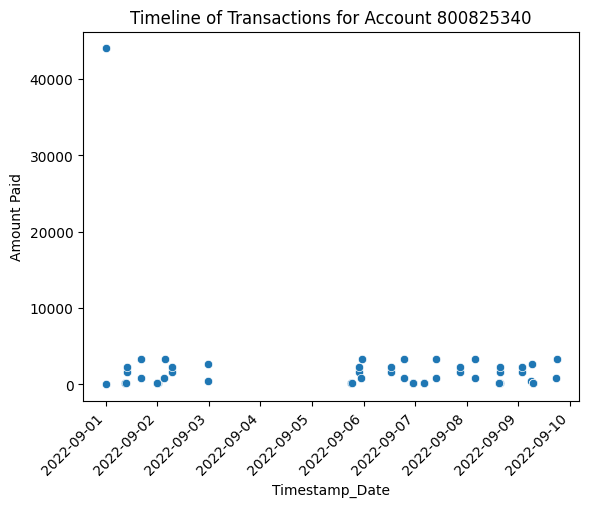

In [29]:
hi_transactions_sample = hi_small_trans_df[hi_small_trans_df['Account'] == '800825340']
hi_transactions_sample['Timestamp_Date'] = pd.to_datetime(hi_transactions_sample['Timestamp'])
sns.scatterplot(hi_transactions_sample, x="Timestamp_Date", y="Amount Paid")
plt.xticks(rotation=45, horizontalalignment='right')
plt.title("Timeline of Transactions for Account 800825340")
None

## Conclusions

The IBM synthetic accounts/transactions dataset is high quality. There are no missing values to handle. There are some duplicates instances, but none that we need to drop. Additionally, there are a large number of instances we can use for analysis.

In the boxplots, we can see some outliers for the Amount Recieved/Paid features. The outliers are for large amounts. The majority of transactions are for small sums

The Amount Received/Paid features are highly correlated. This is because they are equal and opposite to each other. Having the duplicate information will be useful for building the full relationship of transactions for a given account

Looking at a sample account which had fraudulent transaction, we see a number of smaller transactions and single large transaction. One strategy that a fraudster might utilize is spending a large sum from an account they have taken over. This does not cover all possible methods though. More in depth analysis will be needed to uncover these patterns.

The largest challenge with this dataset is that feature engineering is required before analysis. There is only a small number of features. The real insights into fraud will come from building up a full picture of the transactions for each account. From here the model can learn what types of transactions are dissimilar to normal ones. One strategy I will employ is creating an engineered feature to represent the average purchase amount for an account, as well as the amount of times two accounts have sent money to each other.